# Atividade prática: Mineração de Dados - Semana 05

Notebook criado para acompanhar as atividades práticas da Semana 05, apresentadas pela disciplina de **Mineração de Dados** da **UNIVESP**.

## Objetivos da Semana 05:

Utilizar o algoritmo **complete-linkage** para analisar um conjunto de dados socioeconômicos de diferentes países. Gerar um dendograma e um gráfico de dispersão dos dados.

## Exercícios:

Para fazer a análise, selecionar os atrinutos **child_mort** e **life_expec** usando 4 grupos, e, como medida de similaridade, usar a distância euclidiana.  
Responda também:
1. Quais são os países que têm as piores taxas de mortalidade e expectativa de vida?
2. Quais têm as melhores taxas?

### Base de Dados:
https://raw.githubusercontent.com/higoramario/univesp-com360-mineracao-dados/refs/heads/main/country-data.csv

### Sobre o dataframe:

O **dicionário de dados** da base é o seguinte:

* **country**: nome do país;
* **child_mort**: mortalidade infantil de crianças até 5 anos a cada mil nascidos;
* **exports**: percentual de participação das exportações no PIB;
* **health**: percentual de gastos com saúde em relação ao PIB;
* **imports**: percentual de participação das importações no PIB;
* **income**: renda anual per capita;
* **inflation**: taxa de crescimento anual do PIB;
* **life_expec**: expectatva de vida de acordo com a taxa de mortalidade;
* **total_fer**: número de crianças que poderiam nascer por mulher de acordo com as taxas de fertilidade/idade;
* **gdpp**: PIB per capita.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc # utilizada para plotar o dendograma
from sklearn.cluster import AgglomerativeClustering # para fazer agrupamentos hierárquicos

In [2]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com360-mineracao-dados/refs/heads/main/country-data.csv'
df = pd.read_csv(url)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Com a função `df(info)` descobre-se que não há nenhum dado nulo neste dataframe:


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


Um novo dataframe é criado selecionando apenas as colunas 'child_mort' (mortalidade infantil) e 'life_expec' (expectativa de vida) do DataFrame original. Ele é posteriormente usado para plotar o Dendograma.

In [4]:
df_agrup = df[['child_mort', 'life_expec']]
df_agrup.head()

,child_mort,life_expec
0,90.2,56.2
1,16.6,76.3
2,27.3,76.5
3,119.0,60.1
4,10.3,76.8


O código abaixo cria e exibe um dendrograma, que é uma representação visual da hierarquia de agrupamentos dos dados:

* `plt.figure(figsize=(15, 10))`: especifica o tamanho da figura (15 polegadas de largura por 10 polegadas de altura). Isso garante que o dendrograma tenha um bom espaço para ser exibido;
* `plt.title('Dendograma')`: Define o título do gráfico como 'Dendograma', tornando-o mais fácil de identificar;
* `dendograma = shc.dendrogram(shc.linkage(df_agrup, method='complete')):
shc.linkage(df_agrup, method='complete')`: realiza o agrupamento hierárquico nos dados contidos em `df_agrup`. O parâmetro `method='complete'` define a regra de agrupamento: ele calcula a distância entre dois grupos olhando para a maior distância entre quaisquer dois países (um de cada grupo). O resultado dessa operação não é o gráfico em si, mas uma 'matriz de ligação', que funciona como um manual detalhado de como os países foram se unindo e a que distância cada união ocorreu, servindo de base para a construção visual do dendrograma.


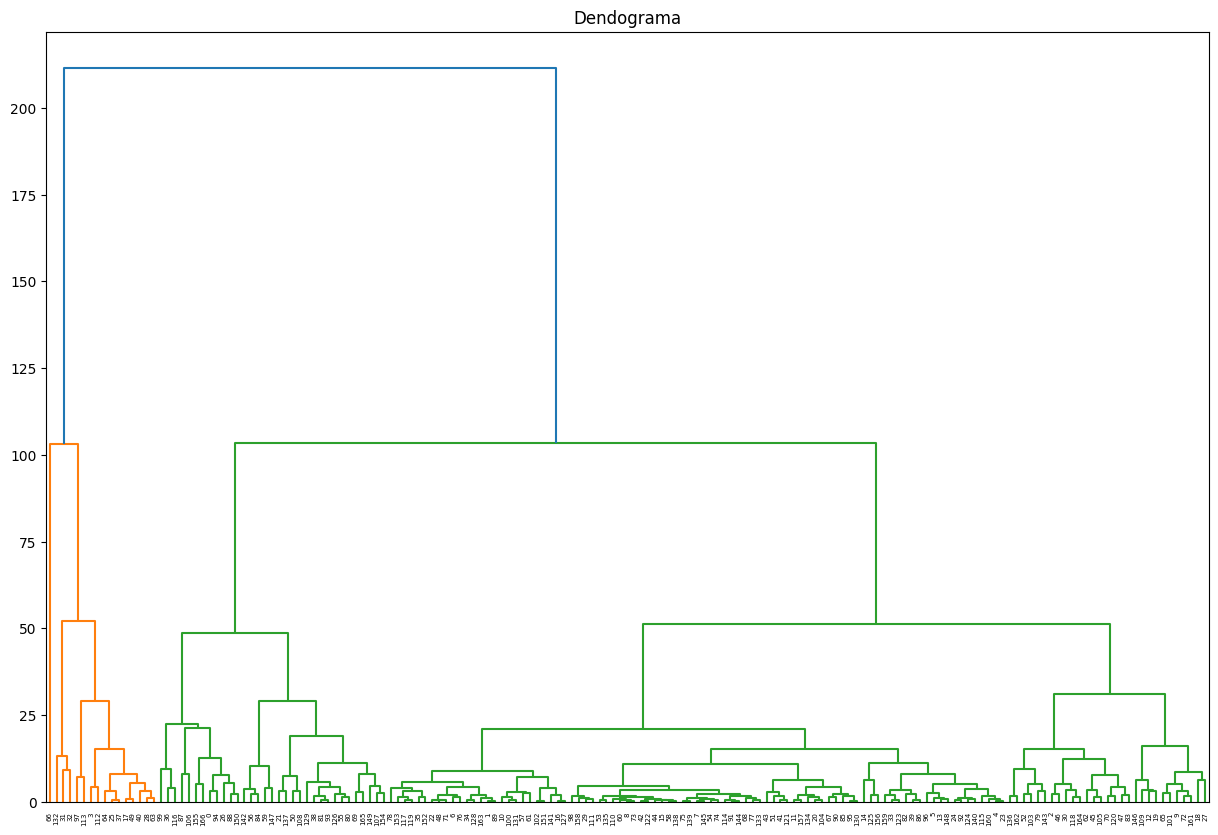

In [29]:
plt.figure(figsize=(15, 10))
plt.title('Dendograma')
dendograma = shc.dendrogram(shc.linkage(df_agrup, method='complete'))

Agora, o algoritmo de agrupamento hierárquico aglomerativo é configurado e aplicado aos dados:

* `n_grupos = 4`: Esta linha define o número desejado de clusters (grupos) que o algoritmo irá formar;
* `grupos = AgglomerativeClustering(n_clusters=n_grupos, metric='euclidean', linkage='complete')`: Aqui, é criada uma instância do algoritmo `AgglomerativeClustering` com configurações específicas:
    * `n_clusters=n_grupos`: Informa ao algoritmo para formar o número de grupos definido;
    * `metric='euclidean'`: Especifica que a distância entre os pontos (países) deve ser calculada usando a distância Euclidiana, que é a distância 'em linha reta' entre dois pontos em um espaço multidimensional;
    * `linkage='complete'`: Indica ao algoritmo para usar o método 'complete linkage' para calcular a distância entre os clusters. Isso significa que a distância entre dois clusters é determinada pela maior distância entre quaisquer dois pontos, um de cada cluster.
* `grupos.fit_predict(df_agrup)`: Executa o algoritmo de agrupamento. Ele 'aprende' com os dados em `df_agrup` (que contêm 'child_mort' e 'life_expec') e, em seguida, atribui cada país a um dos 4 clusters formados. O resultado é um array que indica a qual grupo cada linha (país) do `df_agrup` pertence.

In [14]:
n_grupos = 4
grupos = AgglomerativeClustering(n_clusters=n_grupos, metric='euclidean', linkage='complete')
grupos.fit_predict(df_agrup)

array([2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2,
       1, 1, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 1, 1, 2, 0, 2, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 0, 0, 1,
       3, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2,
       2, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1,
       1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1,
       0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2])

Para visualizar os resultados do agrupamento que você realizado, são utilizados os comandos:

* `plt.scatter(df_agrup['child_mort'], df_agrup['life_expec'], c=grupos.labels_,cmap='rainbow')`:
    * `plt.scatter()`: Esta função é usada para criar um gráfico de dispersão, onde cada ponto representa um país;
    * `df_agrup['child_mort']`: Define os valores para o eixo X do gráfico (mortalidade infantil);
    * `df_agrup['life_expec']`: Define os valores para o eixo Y do gráfico (expectativa de vida);
    * `c=grupos.labels_`: Instrui o Matplotlib a colorir cada ponto do gráfico com base no grupo (cluster) ao qual ele foi atribuído pelo algoritmo `AgglomerativeClustering`. Assim, países do mesmo grupo terão a mesma cor;
    * `cmap='rainbow'`: Define o mapa de cores a ser usado, garantindo que os diferentes grupos sejam facilmente distinguíveis visualmente.
* `plt.xlabel('Mortalidade infantil')`: Adiciona um rótulo ao eixo X para identificar o que ele representa;
* `plt.ylabel('Expectativa de vida')`: Adiciona um rótulo ao eixo Y para identificar o que ele representa;
* `plt.show()`: Exibe o gráfico de dispersão final com os países coloridos de acordo com seus respectivos clusters.

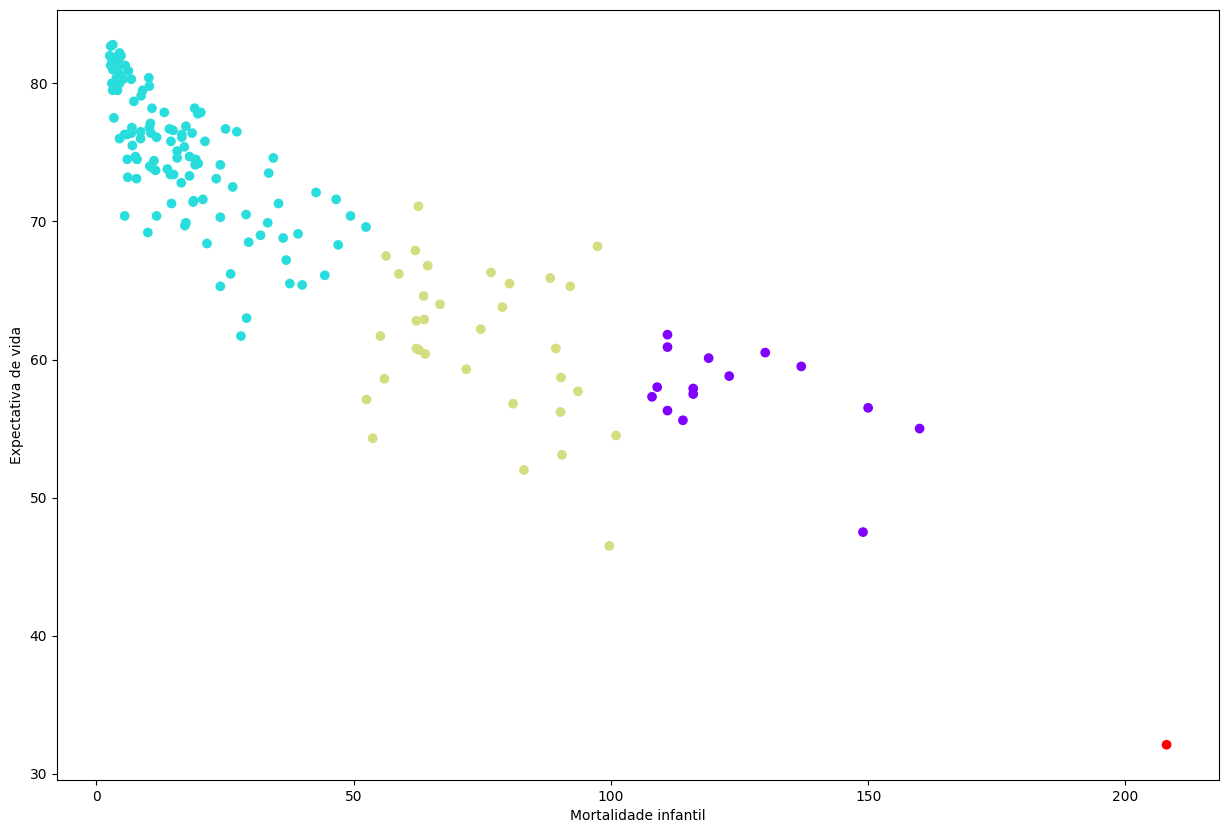

In [15]:
plt.figure(figsize=(15, 10))
plt.scatter(df_agrup['child_mort'], df_agrup['life_expec'], c=grupos.labels_,cmap='rainbow')
plt.xlabel('Mortalidade infantil')
plt.ylabel('Expectativa de vida')
plt.show()

1. Quais são os países que têm as piores taxas de mortalidade e expectativa de vida?

*Através do gráfico de dispersão, é possível notar que existe um país (em vermelho) cuja taxa de mortalidade infantil é maior que 200, e a expectativa de vida é menor que 40. Essas informações são utilizadas para verificar o nome deste país na base de dados*

In [17]:
# Pior taxa de mortalidade infantil:
df['country'][df['child_mort'] > 200]

,country
66,Haiti


In [18]:
# Pior expectativa de vida:
df['country'][df['life_expec']< 40]

,country
66,Haiti


2. Quais têm as melhores taxas?

*A mesma lógica é utilizada para verificar quais países estão melhores posicionados no gráfico de dispersão. Os valores "< 3" e "> 82" foram obtidos a partir de tentativa e erro, buscando valores mais próximos aos pontos apresentados no gráfico que limitassem a quantidade de países retornados na busca.*

In [24]:
# Melhor taxa de mortalidade infantil:
df['country'][df['child_mort'] < 3]

,country
68,Iceland
91,Luxembourg
133,Singapore


In [28]:
# Melhor expectativa de vida:
df['country'][df['life_expec'] > 82]

,country
77,Japan
133,Singapore
145,Switzerland
